In [1]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain-core langchain-perplexity

In [2]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("PPLX_API_KEY")

PPLX_API_KEY:  ········


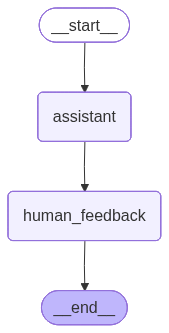

In [3]:
from typing_extensions import TypedDict
from typing import List

from IPython.display import Image, display

from langchain_perplexity import ChatPerplexity
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver

class State(MessagesState):
    feedback: str | None

llm = ChatPerplexity(model="sonar-pro")

def assistant(state: State, config: RunnableConfig) -> State:
    messages: List[BaseMessage] = state.get("messages", [])
    response = llm.invoke(messages, config=config)
    return {
        "messages": messages + [response],
        "feedback": state.get("feedback"),
    }

def human_feedback(state: State, config: RunnableConfig) -> State:
    messages: List[BaseMessage] = state.get("messages", [])
    fb = state.get("feedback")

    if fb and messages:
        last = messages[-1]
        if isinstance(last, AIMessage):
            edited = AIMessage(content=fb)
            messages = messages[:-1] + [edited]

    return {
        "messages": messages,
        "feedback": fb,
    }

workflow = StateGraph(State)
workflow.add_node("assistant", assistant)
workflow.add_node("human_feedback", human_feedback)
workflow.add_edge(START, "assistant")
workflow.add_edge("assistant", "human_feedback")
workflow.add_edge("human_feedback", END)

memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
from langchain_core.messages import HumanMessage

thread = {"configurable": {"thread_id": "feedback-demo-1"}}

initial_input = {
    "messages": [HumanMessage(content="Write a short friendly intro about learning Python.")],
    "feedback": None,
}

print("Running graph to get the first model response...\n")
last_message = None
for event in graph.stream(initial_input, config=thread, stream_mode="values"):
    last_message = event["messages"][-1]
    last_message.pretty_print()
    print("-" * 40)

if last_message is None:
    print("No messages generated.")

Running graph to get the first model response...

================================ Human Message =================================

Write a short friendly intro about learning Python.
----------------------------------------
================================== Ai Message ==================================

# Getting Started with Python

Python is one of the most **beginner-friendly programming languages** you can learn today.[2][7] Whether you're interested in web development, data science, artificial intelligence, or automation, Python is an excellent starting point.

## Why Python is Perfect for Beginners

The beauty of Python lies in its **simplicity and readability**.[2] The syntax reads almost like plain English, making it far easier to understand and write code compared to many other programming languages.[5] You don't need any prior programming experience—Python is designed to welcome newcomers while still being powerful enough for professional software development.[7]

Python al

In [5]:
print("Current stored state for this thread:")
state = graph.get_state(thread)
print(state)

Current stored state for this thread:
StateSnapshot(values={'messages': [HumanMessage(content='Write a short friendly intro about learning Python.', additional_kwargs={}, response_metadata={}, id='6434f61d-3c1a-428d-b4ca-a20eaa5e390f'), AIMessage(content="# Getting Started with Python\n\nPython is one of the most **beginner-friendly programming languages** you can learn today.[2][7] Whether you're interested in web development, data science, artificial intelligence, or automation, Python is an excellent starting point.\n\n## Why Python is Perfect for Beginners\n\nThe beauty of Python lies in its **simplicity and readability**.[2] The syntax reads almost like plain English, making it far easier to understand and write code compared to many other programming languages.[5] You don't need any prior programming experience—Python is designed to welcome newcomers while still being powerful enough for professional software development.[7]\n\nPython also runs on an **interpreter system**, which

In [6]:
user_feedback_text = "Python is a versatile programming language used for data analysis, web development, and automation. It is beginner-friendly and widely adopted."

print("Applying human feedback by editing the last AI message...")

graph.update_state(
    thread,
    {"feedback": user_feedback_text},
    as_node="human_feedback",
)

print("Resuming the graph from the human_feedback node...\n")
for event in graph.stream(None, config=thread, stream_mode="values"):
    event["messages"][-1].pretty_print()
    print("-" * 40)

Applying human feedback by editing the last AI message...
Resuming the graph from the human_feedback node...

================================== Ai Message ==================================

# Getting Started with Python

Python is one of the most **beginner-friendly programming languages** you can learn today.[2][7] Whether you're interested in web development, data science, artificial intelligence, or automation, Python is an excellent starting point.

## Why Python is Perfect for Beginners

The beauty of Python lies in its **simplicity and readability**.[2] The syntax reads almost like plain English, making it far easier to understand and write code compared to many other programming languages.[5] You don't need any prior programming experience—Python is designed to welcome newcomers while still being powerful enough for professional software development.[7]

Python also runs on an **interpreter system**, which means you can execute your code immediately after writing it.[2] This i

In [7]:
thread2 = {"configurable": {"thread_id": "feedback-demo-2"}}

initial_input2 = {
    "messages": [HumanMessage(content="Give me a concise explanation of what an API is.")],
    "feedback": None,
}

print("Running a second example thread...\n")
for event in graph.stream(initial_input2, config=thread2, stream_mode="values"):
    event["messages"][-1].pretty_print()
    print("-" * 40)

print("Now editing the answer to be even shorter...")

short_feedback = "An API is a defined way for two software systems to communicate and exchange data."

graph.update_state(
    thread2,
    {"feedback": short_feedback},
    as_node="human_feedback",
)

print("\nResuming the second thread from human_feedback with the edited answer...\n")
for event in graph.stream(None, config=thread2, stream_mode="values"):
    event["messages"][-1].pretty_print()
    print("-" * 40)

Running a second example thread...

================================ Human Message =================================

Give me a concise explanation of what an API is.
----------------------------------------
================================== Ai Message ==================================

An **API** (Application Programming Interface) is a set of rules and protocols that allows different software applications to communicate, exchange data, and use each other's features without knowing their internal workings[1][3][5][9].

APIs act as intermediaries, defining how requests for information or actions should be made and how responses are delivered. For example, a weather app uses an API to request current weather data from a remote server, which then returns the data in a structured format like JSON or XML[1][2].

By providing a standardized interface, APIs enable software developers to integrate systems, automate tasks, and build on top of existing platforms efficiently, which accelerates